# Q3 + Q9 — Forecast Uncertainty & Cold-Start Detection
Validates `src/xai/uncertainty.py`.
- **Q3**: How confident is the model in this forecast?
- **Q9**: Is the model less reliable for this SKU due to limited history?

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.uncertainty import (
    compute_sku_residual_std,
    compute_prediction_interval,
    confidence_label,
    detect_cold_start_skus,
    subgroup_evaluation,
    generate_confidence_text,
)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


## 2) Load Model and Data

In [2]:
model    = joblib.load(MODEL_PATH)
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET].copy()

# Training predictions needed to compute per-SKU residual std
train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

print(f'Train rows: {len(X_train)} | Test rows: {len(X_test)}')
print(f'Train MAE: {np.mean(np.abs(train_preds - y_train)):.3f}')
print(f'Test  MAE: {np.mean(np.abs(test_preds  - y_test )):.3f}')

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
Train rows: 68976 | Test rows: 15807
Train MAE: 4.372
Test  MAE: 4.906


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3) Compute Per-SKU Residual Std (Q3 basis)

In [3]:
sku_std = compute_sku_residual_std(y_train, train_preds, train_df['item_id'])

print(f'SKUs with residual std computed: {len(sku_std)}')
print(f'Global residual std:  {sku_std.mean():.3f}')
print(f'Min SKU residual std: {sku_std.min():.3f}')
print(f'Max SKU residual std: {sku_std.max():.3f}')
print()
print('Top 10 most uncertain SKUs:')
print(sku_std.sort_values(ascending=False).head(10))

SKUs with residual std computed: 1437
Global residual std:  5.959
Min SKU residual std: 0.525
Max SKU residual std: 145.726

Top 10 most uncertain SKUs:
item_id
FOODS_3_090    145.726439
FOODS_3_120     66.736312
FOODS_3_282     58.839680
FOODS_3_681     57.057768
FOODS_3_785     50.599962
FOODS_3_501     48.566467
FOODS_3_202     45.332581
FOODS_3_295     43.876639
FOODS_3_739     39.088039
FOODS_3_252     37.870797
Name: residual, dtype: float64


## 4) Compute Prediction Intervals for Test SKUs

In [4]:
global_std = float(sku_std.mean())

interval_rows = []
for i, (pred, sku) in enumerate(zip(test_preds, test_df['item_id'])):
    std   = float(sku_std.get(sku, global_std))
    ivl   = compute_prediction_interval(float(pred), std)
    label = confidence_label(ivl['width'], ivl['q50'])
    interval_rows.append({'item_id': sku, 'q10': ivl['q10'], 'q50': ivl['q50'],
                          'q90': ivl['q90'], 'width': ivl['width'], 'confidence': label})

intervals_df = pd.DataFrame(interval_rows)
print('Confidence distribution across test rows:')
print(intervals_df['confidence'].value_counts())
print()
print(intervals_df.head(10).to_string(index=False))

Confidence distribution across test rows:
confidence
low         12279
moderate     3329
high          199
Name: count, dtype: int64

    item_id  q10  q50  q90  width confidence
FOODS_1_001 1.10 4.54 7.99   6.89        low
FOODS_1_001 1.02 4.46 7.90   6.89        low
FOODS_1_001 0.95 4.40 7.84   6.89        low
FOODS_1_001 0.84 4.28 7.73   6.89        low
FOODS_1_001 0.75 4.19 7.64   6.89        low
FOODS_1_001 1.16 4.61 8.05   6.89        low
FOODS_1_001 2.21 5.65 9.09   6.89        low
FOODS_1_001 1.10 4.55 7.99   6.89        low
FOODS_1_001 2.35 5.79 9.23   6.89        low
FOODS_1_001 1.02 4.46 7.91   6.89        low


## 5) Visualize Prediction Intervals for a Sample SKU

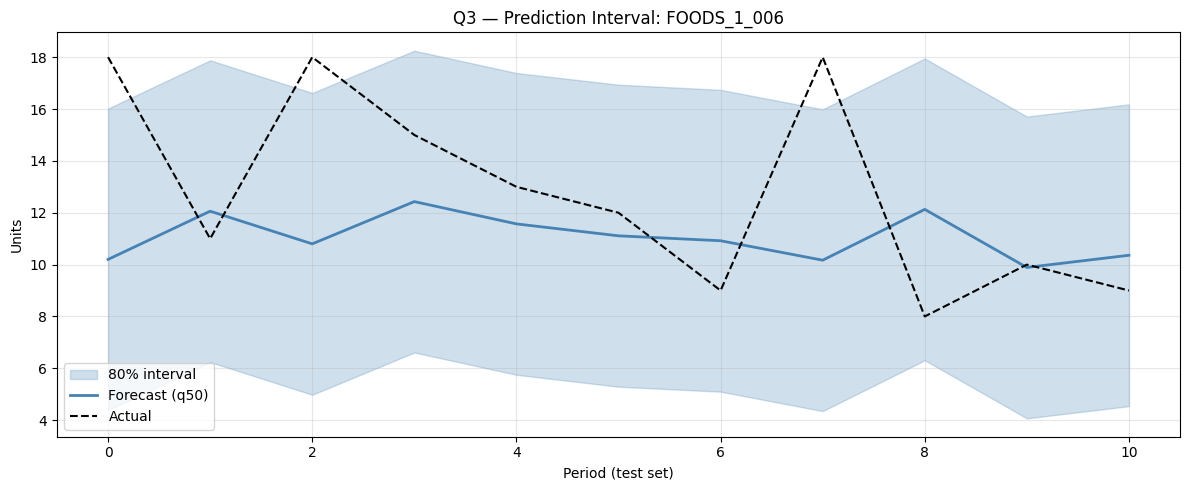

In [5]:
# Pick a SKU with moderate confidence for a clear visual
sample_sku = intervals_df[intervals_df['confidence'] == 'moderate']['item_id'].iloc[0]
sku_rows   = intervals_df[intervals_df['item_id'] == sample_sku].reset_index(drop=True)
actual     = test_df[test_df['item_id'] == sample_sku][TARGET].values

x = range(len(sku_rows))
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x, sku_rows['q10'], sku_rows['q90'], alpha=0.25, color='steelblue', label='80% interval')
ax.plot(x, sku_rows['q50'],  color='steelblue', linewidth=2,   label='Forecast (q50)')
ax.plot(x, actual,           color='black',     linewidth=1.5, linestyle='--', label='Actual')
ax.set_xlabel('Period (test set)')
ax.set_ylabel('Units')
ax.set_title(f'Q3 — Prediction Interval: {sample_sku}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6) Detect Cold-Start SKUs (Q9)

In [10]:
cold_df = detect_cold_start_skus(
    df               = train_df,
    sku_col          = 'item_id',
    weeks_col        = 'weeks_since_first_seen',
    min_history_weeks = 13,
)

n_cold = int(cold_df['is_cold_start'].sum())
print(f'Total SKUs:       {len(cold_df)}')
print(f'Cold-start SKUs:  {n_cold} ({n_cold/len(cold_df)*100:.1f}%)')
print(f'Established SKUs: {len(cold_df) - n_cold}')
print()
print(f'weeks_since_first_seen range: {cold_df["max_weeks_seen"].min()} – {cold_df["max_weeks_seen"].max()}')
print()
if n_cold == 0:
    print('NOTE: No cold-start SKUs detected in this dataset.')
    print('All items have been present since the start of the training window (M5 dataset).')
    print('Cold-start detection is implemented and would flag new SKUs in a production setting.')
    print()
    print('Random sample of SKUs (all established):')
    print(cold_df.sample(10, random_state=42).to_string(index=False))
else:
    print('Cold-start SKUs (fewest weeks of history):')
    print(cold_df[cold_df['is_cold_start']].head(10).to_string(index=False))

Total SKUs:       1437
Cold-start SKUs:  0 (0.0%)
Established SKUs: 1437

weeks_since_first_seen range: 47 – 47

NOTE: No cold-start SKUs detected in this dataset.
All items have been present since the start of the training window (M5 dataset).
Cold-start detection is implemented and would flag new SKUs in a production setting.

Random sample of SKUs (all established):
     sku_id  max_weeks_seen  is_cold_start
FOODS_2_380              47          False
FOODS_3_142              47          False
FOODS_3_017              47          False
FOODS_3_525              47          False
FOODS_3_293              47          False
FOODS_3_420              47          False
FOODS_3_150              47          False
FOODS_3_764              47          False
FOODS_2_044              47          False
FOODS_2_102              47          False


## 7) Subgroup Evaluation: Cold-Start vs Established (Q9)

In [7]:
# Map cold-start flag onto test set
cold_map  = cold_df.set_index('sku_id')['is_cold_start'].to_dict()
test_groups = test_df['item_id'].map(lambda s: 'cold_start' if cold_map.get(s, False) else 'established')

subgroup_df = subgroup_evaluation(y_test.values, test_preds, test_groups)
print(subgroup_df.to_string(index=False))
print()
if len(subgroup_df) == 2:
    cold_mae = subgroup_df[subgroup_df['group'] == 'cold_start']['MAE'].values
    est_mae  = subgroup_df[subgroup_df['group'] == 'established']['MAE'].values
    if len(cold_mae) and len(est_mae):
        print(f'Cold-start MAE is {cold_mae[0]/est_mae[0]:.2f}x higher than established SKUs')

      group     n    MAE  RMSE  SMAPE    BIAS
established 15807 4.9057 9.694  66.42 -0.1605



## 8) Interval Coverage Check

In [8]:
# How often does the actual value fall inside the 80% interval?
actuals     = y_test.values
q10_arr     = intervals_df['q10'].values
q90_arr     = intervals_df['q90'].values
covered     = ((actuals >= q10_arr) & (actuals <= q90_arr)).mean()

print(f'Target coverage (80% interval): 80.0%')
print(f'Actual coverage:                {covered*100:.1f}%')
print()
if covered >= 0.75:
    print('Coverage is acceptable — intervals are well-calibrated.')
else:
    print('Coverage is below target — intervals may be too narrow.')

Target coverage (80% interval): 80.0%
Actual coverage:                77.8%

Coverage is acceptable — intervals are well-calibrated.


## 9) NLG Confidence Statement

In [9]:
demo_sku   = sample_sku
demo_pred  = float(test_preds[test_df['item_id'] == demo_sku][0])
demo_std   = float(sku_std.get(demo_sku, global_std))
demo_cold  = bool(cold_map.get(demo_sku, False))

text = generate_confidence_text(
    sku_id       = demo_sku,
    q50          = demo_pred,
    residual_std = demo_std,
    is_cold_start= demo_cold,
    forecast_window = 7,
)
print(text)

=== Forecast Confidence: FOODS_1_006 ===
Point forecast (next 7 days): 10.2 units
80% prediction interval: [4.4, 16.0]  (width: 11.6 units)
Confidence level: LOW
The model has low confidence — the forecast range is wide and should be treated with caution.

This SKU has sufficient history — cold-start risk is low.
